# ⚖️ __Machine Learning - Decision Trees__🌿
---

In [27]:
#MAIN IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap

In [28]:
#READING DATA
df = pd.read_csv("Decision_Tree_data.csv")
df = df.drop(columns="Unnamed: 0", axis = 1)

In [21]:
df.head()

,Metros_Cuadrados,Distancia_Centro,Antiguedad,Precio
0,37.550907,1.714895,23.958091,267.548086
1,199.381322,8.129217,29.248818,452.842911
2,120.834123,6.035152,29.748396,218.907877
3,186.396991,12.365284,26.979926,481.507850
4,244.937588,4.617595,22.138486,507.542182


## __📝 Dataset description__
---

This dataset contains numerical features related to residential properties, likely used for predictive modeling or market analysis of property values.

#### 📊 **Análisis de Datos Inmobiliarios: Diccionario del Dataset** 🔍
#### 🛠️ Estructura y Definición de Variables

| ID | Column | Type | Description |
| :--- | :--- | :--- | :--- |
| **0** | <font color="#7abaff">`Metros_Cuadrados`</font> | `Float` | The total living area of the property measured in square meters (m²). |
| **1** | <font color="#7abaff">`Distancia_Centro`</font> | `Float` | The geographical distance from the property to the city center (typically measured in kilometers).|
| **2** | <font color="#7abaff">`Antiguedad`</font> | `Float` | The age of the building or property in years since its construction. |
| **3** | <font color="#8ce99a">`Precio`</font> | `Float` | **(Target).** Float	The market value or sale price of the property (currency unit not specified, e.g., Thousands of USD). |

## __Let's visualize a Scatter plot and correlation matrix__
---

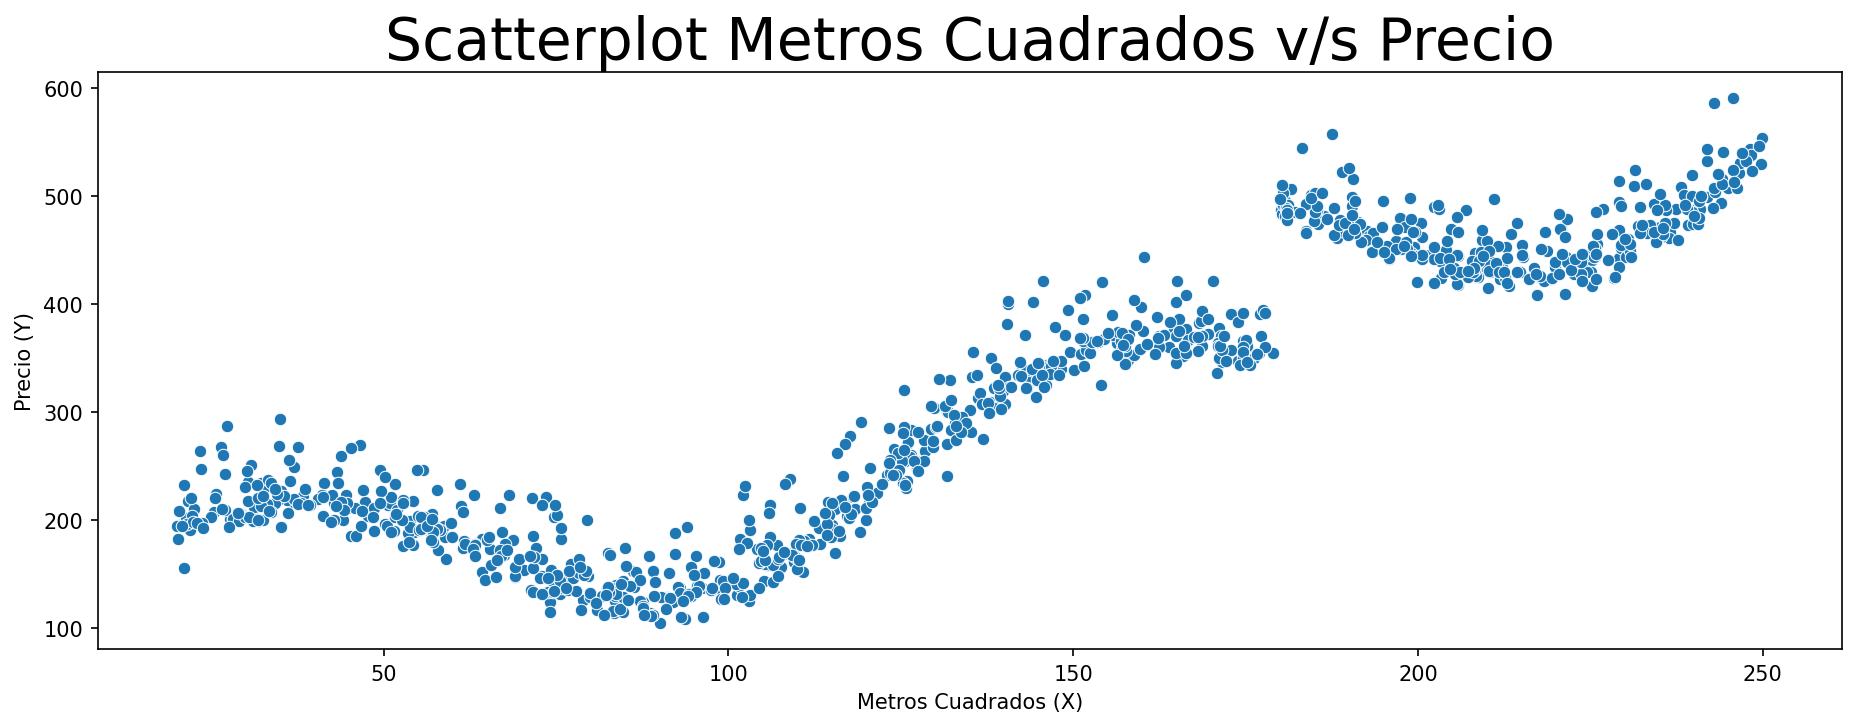

In [42]:
plt.figure(figsize = (15,5), dpi = 150)
sns.scatterplot(data = df, x = 'Metros_Cuadrados', y = 'Precio')
plt.title("Scatterplot Metros Cuadrados v/s Precio", fontsize = 28)
plt.xlabel("Metros Cuadrados (X)")
plt.ylabel("Precio (Y)")
plt.show()

In [43]:
corr = df.corr(method = 'pearson')
corr

,Metros_Cuadrados,Distancia_Centro,Antiguedad,Precio
Metros_Cuadrados,1.000000,-0.004230,0.042318,0.884755
Distancia_Centro,-0.004230,1.000000,-0.007693,-0.101109
Antiguedad,0.042318,-0.007693,1.000000,0.020249
Precio,0.884755,-0.101109,0.020249,1.000000


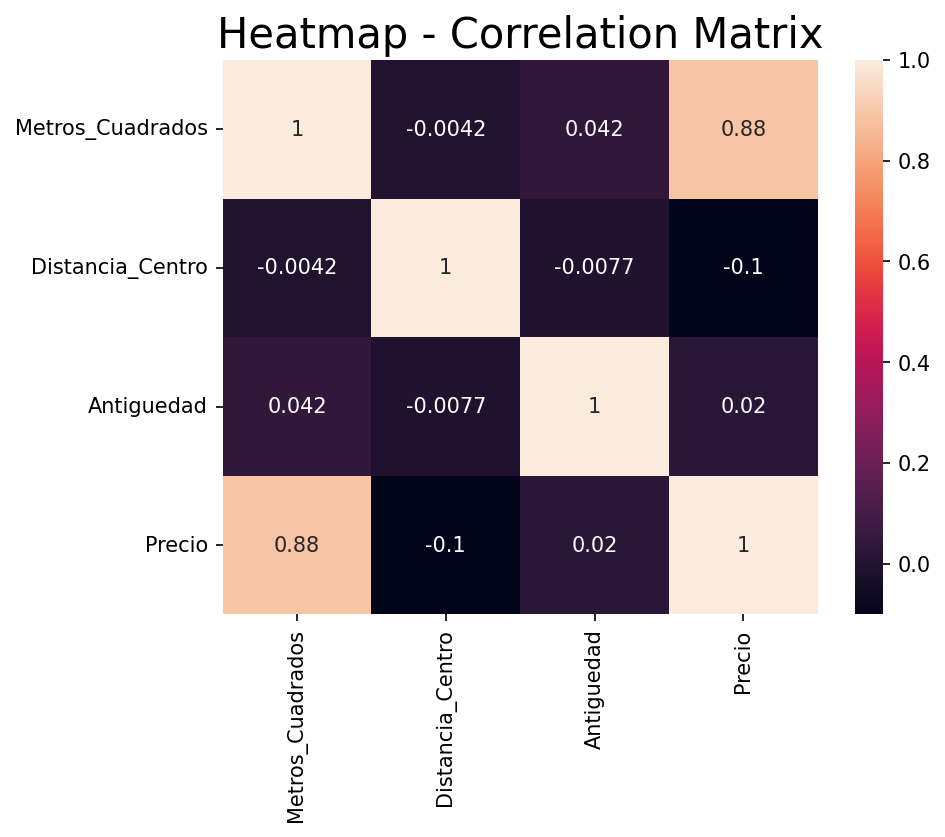

In [58]:
plt.figure(dpi = 150)
sns.heatmap(corr, annot = True)
plt.title("Heatmap - Correlation Matrix", fontsize = 20)
plt.show()

## __Simple Linear Regression v/s Decision Tree__
---

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


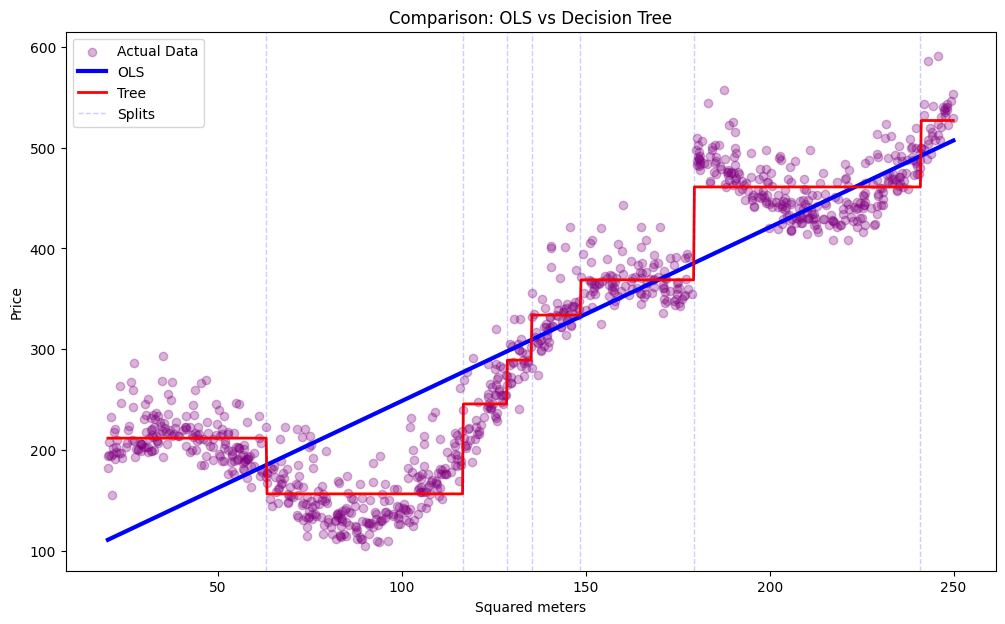

,Simple OLS,Regression Tree
Metric,,
R2 Score,0.7828,0.9605
MSE,3636.5775,660.4948
RMSE,60.3040,25.7001
MAE,48.0195,20.2476
MAPE,0.2276,0.0815


In [49]:
# 1. MODEL FITTING

X_s = df[['Metros_Cuadrados']]
y = df['Precio']

# FIT ORDINARY LEAST SQUARES MODEL
model_ols_s = sm.OLS(y, sm.add_constant(X_s)).fit()

# FIT DECISION TREE REGRESSOR WITH DEPTH CONSTRAINT
tree_s = DecisionTreeRegressor(max_depth=3)
tree_s.fit(X_s, y)

# 2. SPLIT EXTRACTION
# THE FEATURE != -2 FILTER ENSURES ONLY ACTUAL DIVISION POINTS ARE PLOTTED
cuts = tree_s.tree_.threshold[tree_s.tree_.feature != -2]

# 3. PREDICTIONS
y_pred_ols = model_ols_s.predict(sm.add_constant(X_s))
y_pred_tree = tree_s.predict(X_s)

# 4. CREATION OF THE METRICS DATAFRAME (INCLUDING RMSE)
metrics_data = {
    "Metric": ["R2 Score", "MSE", "RMSE", "MAE", "MAPE"],
    "Simple OLS": [
        r2_score(y, y_pred_ols),
        mean_squared_error(y, y_pred_ols),
        np.sqrt(mean_squared_error(y, y_pred_ols)), # RMSE
        mean_absolute_error(y, y_pred_ols),
        mean_absolute_percentage_error(y, y_pred_ols)
    ],
    "Regression Tree": [
        r2_score(y, y_pred_tree),
        mean_squared_error(y, y_pred_tree),
        np.sqrt(mean_squared_error(y, y_pred_tree)), # RMSE
        mean_absolute_error(y, y_pred_tree),
        mean_absolute_percentage_error(y, y_pred_tree)
    ]
}

df_metrics = pd.DataFrame(metrics_data).set_index("Metric")

# 5. VISUALIZATION
X_grid = np.linspace(X_s.min(), X_s.max(), 1000).reshape(-1, 1)
plt.figure(figsize=(12, 7))

# SCATTER PLOT FOR ACTUAL DATA AND LINES FOR MODEL PREDICTIONS
plt.scatter(X_s, y, alpha=0.3, color='purple', label='Actual Data')
plt.plot(X_grid, model_ols_s.predict(sm.add_constant(X_grid)), color='blue', lw=3, label='OLS')
plt.plot(X_grid, tree_s.predict(X_grid), color='red', lw=2, label='Tree')
plt.xlabel("Squared meters")
plt.ylabel("Price")
# DRAW VERTICAL LINES FOR TREE SPLITS
for i, cut in enumerate(cuts):
    plt.axvline(x=cut, color='blue', linestyle='--', alpha=0.2, lw=1, label='Splits' if i == 0 else "")

plt.title("Comparison: OLS vs Decision Tree")
plt.legend()
plt.show()

# DISPLAY METRICS RESULTS
display(df_metrics.round(4))

## __Let's check de decision rules__
---

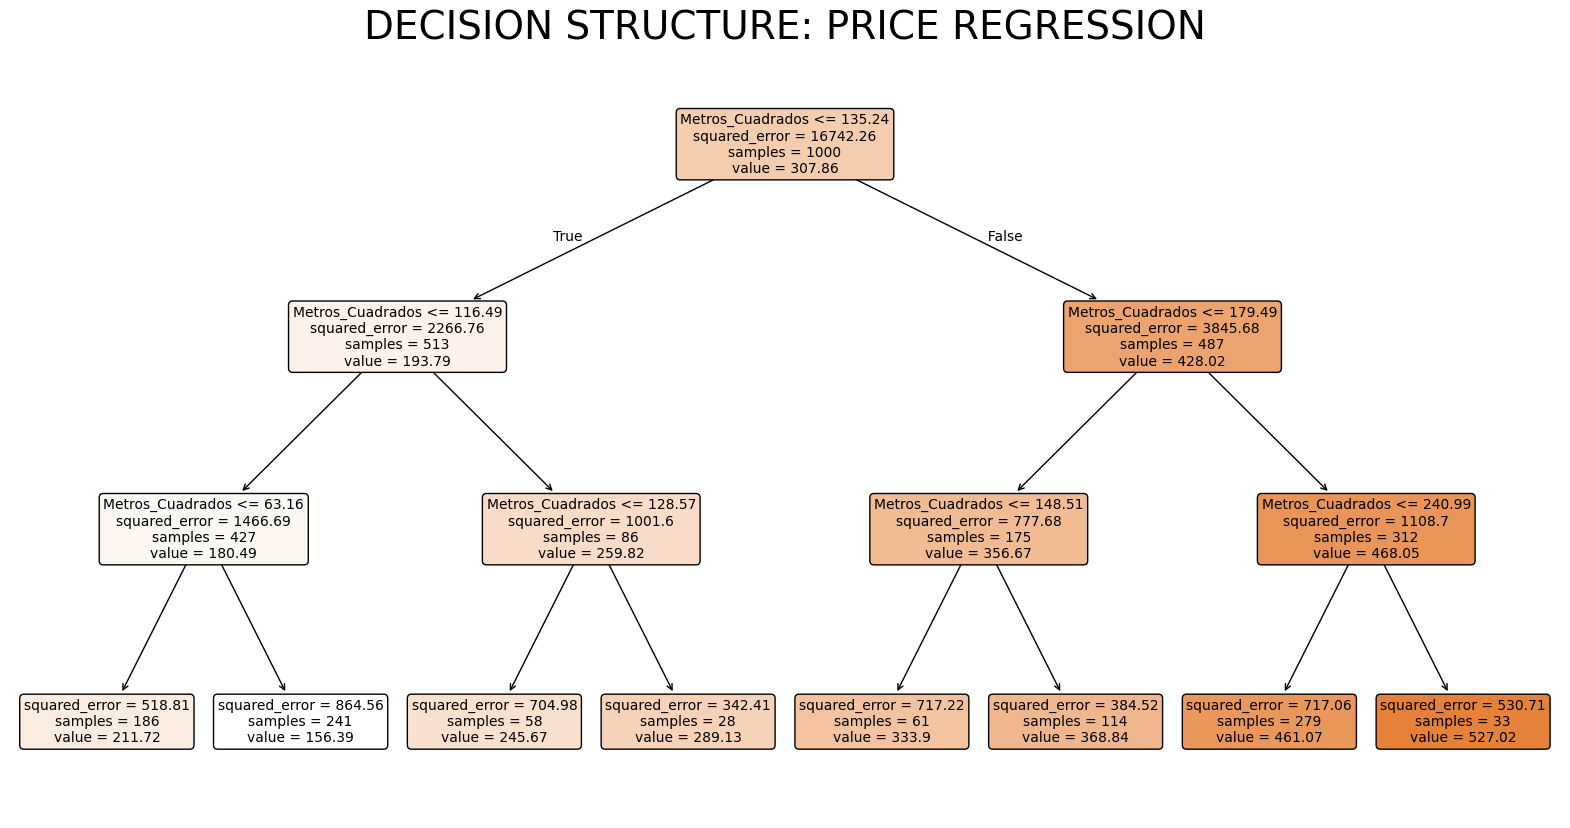

In [50]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_s,
    feature_names=['Metros_Cuadrados'],
    filled=True,          # COLORS NODES ACCORDING TO PREDICTED VALUE
    rounded=True,         # ROUNDED EDGES FOR A MODERN LOOK
    fontsize=10,
    precision=2           # NUMBER OF DECIMAL PLACES
)

# UPDATED TITLE TO ENGLISH AND UPPERCASE
plt.title("DECISION STRUCTURE: PRICE REGRESSION", fontsize=28)
plt.show()

## __Multiple Linear Regression v/s Decision Tree__
---

,Multiple OLS,Regression Tree
Metric,,
R2 Score,0.7926,0.9753
MSE,3472.4654,413.2489
RMSE,58.9276,20.3285
MAE,46.9083,16.0649
MAPE,0.2234,0.0657


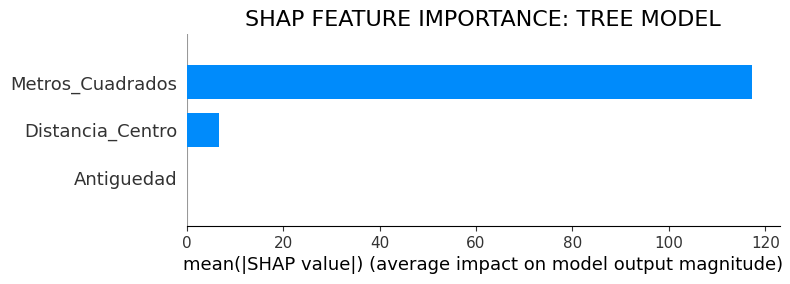

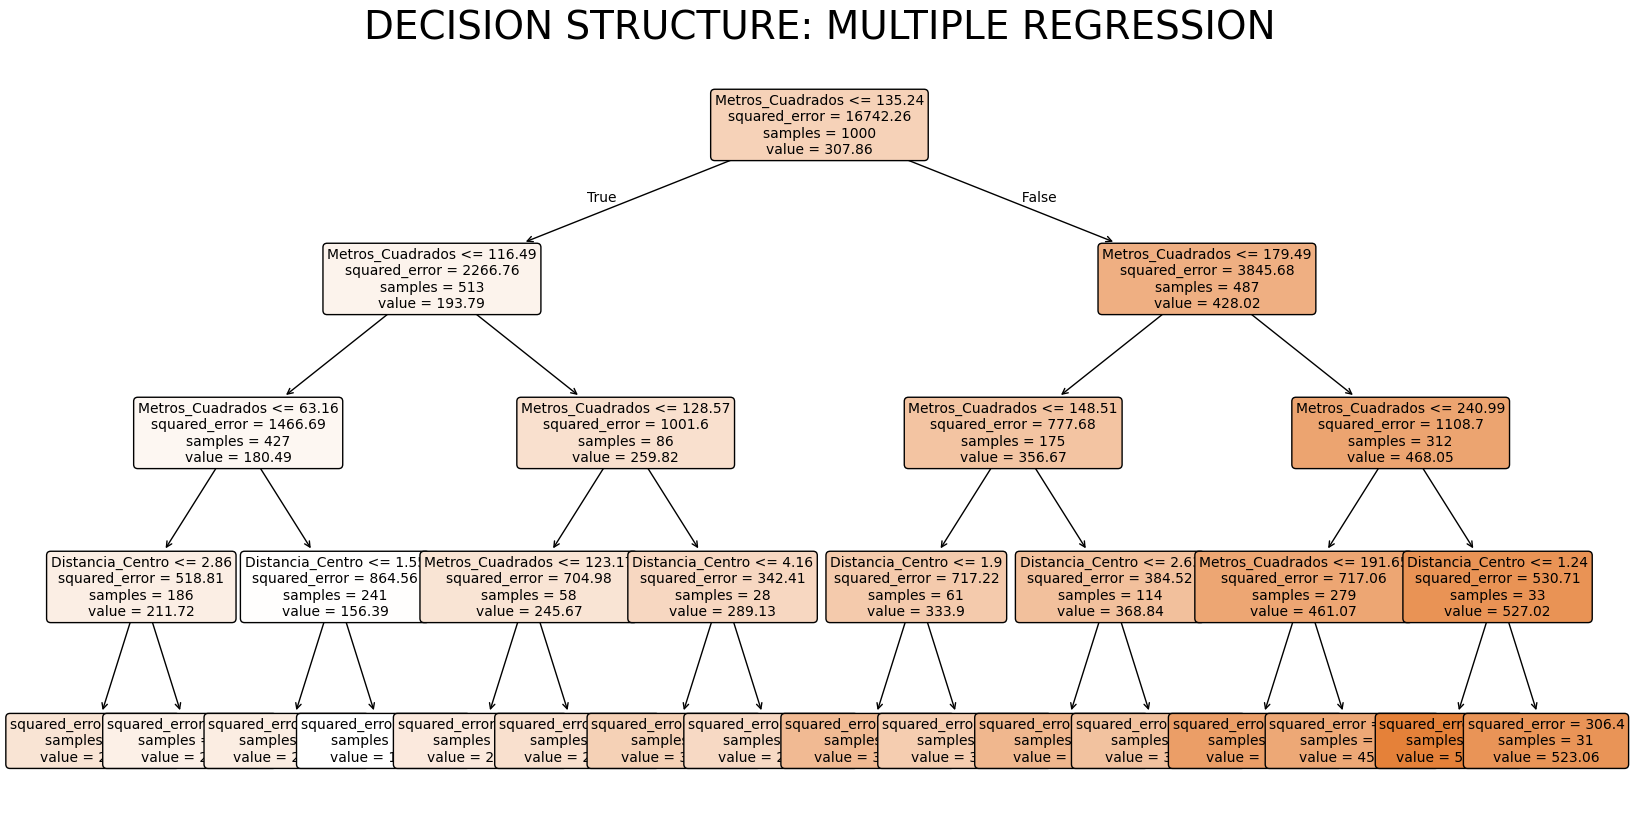

In [36]:
# 1. MODEL FITTING (MULTIPLE REGRESSION)
# DEFINE MULTIPLE FEATURES (X) AND TARGET (Y)
features = ['Metros_Cuadrados', 'Distancia_Centro', 'Antiguedad']
X_m = df[features]
y = df['Precio']

# FIT MULTIPLE LINEAR REGRESSION (OLS)
model_ols_m = sm.OLS(y, sm.add_constant(X_m)).fit()

# FIT DECISION TREE REGRESSOR
tree_m = DecisionTreeRegressor(max_depth=4)
tree_m.fit(X_m, y)

# 2. PREDICTIONS
y_pred_ols = model_ols_m.predict(sm.add_constant(X_m))
y_pred_tree = tree_m.predict(X_m)

# 3. METRICS DATAFRAME
metrics_data = {
    "Metric": ["R2 Score", "MSE", "RMSE", "MAE", "MAPE"],
    "Multiple OLS": [
        r2_score(y, y_pred_ols),
        mean_squared_error(y, y_pred_ols),
        np.sqrt(mean_squared_error(y, y_pred_ols)),
        mean_absolute_error(y, y_pred_ols),
        mean_absolute_percentage_error(y, y_pred_ols)
    ],
    "Regression Tree": [
        r2_score(y, y_pred_tree),
        mean_squared_error(y, y_pred_tree),
        np.sqrt(mean_squared_error(y, y_pred_tree)),
        mean_absolute_error(y, y_pred_tree),
        mean_absolute_percentage_error(y, y_pred_tree)
    ]
}
df_metrics = pd.DataFrame(metrics_data).set_index("Metric")
display(df_metrics.round(4))

# 4. SHAP VALUES VISUALIZATION (INSTEAD OF SCATTER PLOT)
# CALCULATE SHAP VALUES FOR THE DECISION TREE
explainer = shap.TreeExplainer(tree_m)
shap_values = explainer.shap_values(X_m)

# GENERATE SHAP SUMMARY PLOT
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_m, plot_type="bar", show=False)
plt.title("SHAP FEATURE IMPORTANCE: TREE MODEL", fontsize=16)
plt.show()

# 5. TREE STRUCTURE VISUALIZATION
plt.figure(figsize=(20, 10))
plot_tree(
    tree_m,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2
)
plt.title("DECISION STRUCTURE: MULTIPLE REGRESSION", fontsize=28)
plt.show()